# TEXAS ACTIVSG2000 (MATPOWER) case — Dataset Overview

This notebook inspects a **Matpower `.m` case file**:

- file metadata (size, hash)
- Matpower scalars (`mpc.version`, `mpc.baseMVA`)
- core matrices (`bus`, `gen`, `branch`, `gencost`) as DataFrames
- quick consistency checks (IDs, endpoint integrity, connectivity)

---
#### Bootstrap

In [1]:
from _notebook_bootstrap import bootstrap

repo_root, datasets_root = bootstrap()
repo_root, datasets_root

(PosixPath('/home/user/workspace/datasets-utilities'),
 PosixPath('/home/user/data/datasets'))

---
#### Imports

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from dataloaders.matpower_case import MatpowerCase
from dataset_utils.plotting import bar_counts

---
#### Load dataset object

In [3]:
# Select your file (can be changed to any other snapshot path under datasets_root)
relpath = "activsg2000/ACTIVSg2000.m"

ds = MatpowerCase(datasets_root=datasets_root, relpath=relpath)
ds.path

PosixPath('/home/user/data/datasets/activsg2000/ACTIVSg2000.m')

---
#### File overview
Key scalars + which Matpower blocks were detected.

In [4]:
ov = ds.overview()
ov

,key,value
0,path,/home/user/data/datasets/activsg2000/ACTIVS...
1,size_bytes,668069
2,sha256,55e140511bcc527e2c4302a723f40300b1e26fa1679bdd...
3,mpc.version,2
4,mpc.baseMVA,100.0
5,blocks_present,"branch, bus, gen, gencost"
6,bus.rows,2000
7,bus.cols,19
8,gen.rows,544
9,gen.cols,27


---
#### Load tables
Parse Matpower matrices into DataFrames.

In [5]:
tables = ds.load_tables()

shapes = (
    pd.DataFrame([{"table": k, "rows": int(v.shape[0]), "cols": int(v.shape[1])} for k, v in tables.items()])
    .sort_values("table")
    .reset_index(drop=True)
)
shapes

,table,rows,cols
0,branch,3206,24
1,bus,2000,19
2,gen,544,27
3,gencost,544,8


---
#### Core matrices preview

In [6]:
bus = tables.get("bus")
gen = tables.get("gen")
branch = tables.get("branch")
gencost = tables.get("gencost")

display(bus.head(10) if bus is not None else "missing: bus")
display(gen.head(10) if gen is not None else "missing: gen")
display(branch.head(10) if branch is not None else "missing: branch")
display(gencost.head(10) if gencost is not None else "missing: gencost")

,BUS_I,BUS_TYPE,PD,QD,GS,BS,BUS_AREA,VM,VA,BASE_KV,ZONE,VMAX,VMIN,BUS_EXTRA_1,BUS_EXTRA_2,BUS_EXTRA_3,BUS_EXTRA_4,bus_id,in_service
0,1001,1,20.78,5.89,0,0.0,1,0.979436,-22.734844,115.0,9,1.1,0.9,25.75,-3.48,0,0,1001,True
1,1002,1,15.41,4.37,0,0.0,1,1.012736,-18.088545,115.0,9,1.1,0.9,84.21,0.49,0,0,1002,True
2,1003,1,0.0,0.0,0,0.0,1,1.009263,-17.086699,115.0,9,1.1,0.9,-6.74,0.14,0,0,1003,True
3,1004,2,0.0,0.0,0,0.0,1,1.013071,-18.933999,230.0,9,1.1,0.9,-7.08,6.03,0,0,1004,True
4,1005,1,0.0,0.0,0,0.0,1,1.005576,-16.077157,115.0,9,1.1,0.9,-52.96,-29.63,0,0,1005,True
5,1006,2,0.0,0.0,0,0.0,1,1.0,-13.905591,13.8,9,1.1,0.9,-50.44,0.0,0,0,1006,True
6,1007,1,7.01,1.99,0,-0.82,1,1.02,-18.467212,115.0,9,1.1,0.9,73.76,0.0,0,0,1007,True
7,1008,1,0.0,0.0,0,0.0,1,1.019285,-8.605207,115.0,9,1.1,0.9,-680.69,29.86,0,0,1008,True
8,1009,2,0.0,0.0,0,0.0,1,1.00924,-5.309598,13.8,9,1.1,0.9,-680.32,29.76,0,0,1009,True
9,1010,1,0.0,0.0,0,-3.07,1,1.02,-16.792355,115.0,9,1.1,0.9,86.13,0.0,0,0,1010,True


,GEN_BUS,PG,QG,QMAX,QMIN,VG,MBASE,GEN_STATUS,PMAX,PMIN,...,RAMP_10,RAMP_30,RAMP_Q,APF,GEN_EXTRA_1,GEN_EXTRA_2,GEN_EXTRA_3,GEN_EXTRA_4,bus_id,in_service
0,1004,158.25,-30.38,44.94,-30.38,1.01,253.2,1,158.25,158.25,...,0,0,0,211.0,0,0,0,0,1004,True
1,1006,25.73,-4.35,7.31,-4.94,1.0,41.16,1,25.73,25.73,...,0,0,0,34.3,0,0,0,0,1006,True
2,1009,61.87,-11.88,17.57,-11.88,1.0,99.0,1,61.87,61.87,...,0,0,0,82.5,0,0,0,0,1009,True
3,1011,9.97,0.0,0.0,0.0,1.0,12.0,1,10.0,3.0,...,0,0,0,10.0,0,0,0,0,1011,True
4,1021,149.63,-23.15,42.49,-28.73,1.0,239.4,1,149.63,149.63,...,0,0,0,199.5,0,0,0,0,1021,True
5,1023,135.0,2.26,38.34,-25.92,1.01,216.0,1,135.0,135.0,...,0,0,0,180.0,0,0,0,0,1023,True
6,1026,93.15,-3.42,26.45,-17.88,1.0,149.04,1,93.15,93.15,...,0,0,0,124.2,0,0,0,0,1026,True
7,1033,208.5,-40.03,59.21,-40.03,1.0,333.6,1,208.5,208.5,...,0,0,0,278.0,0,0,0,0,1033,True
8,1035,67.5,-6.87,19.17,-12.96,1.0,108.0,1,67.5,67.5,...,0,0,0,90.0,0,0,0,0,1035,True
9,1039,110.63,-16.65,31.42,-21.24,1.0,177.0,1,110.63,110.63,...,0,0,0,147.5,0,0,0,0,1039,True


,F_BUS,T_BUS,BR_R,BR_X,BR_B,RATE_A,RATE_B,RATE_C,TAP,SHIFT,...,BR_EXTRA_2,BR_EXTRA_3,BR_EXTRA_4,BR_EXTRA_5,BR_EXTRA_6,BR_EXTRA_7,BR_EXTRA_8,from_bus,to_bus,in_service
0,1001,1064,0.00524,0.0358,0.00609,221.0,0,0,0,0,...,10.9,-67.21,-9.73,0,0,0,0,1001,1064,True
1,1001,1064,0.00524,0.0358,0.00609,221.0,0,0,0,0,...,10.9,-67.21,-9.73,0,0,0,0,1001,1064,True
2,1001,1071,0.00435,0.02808,0.00536,221.0,0,0,0,0,...,-13.84,78.14,15.15,0,0,0,0,1001,1071,True
3,1001,1071,0.00435,0.02808,0.00536,221.0,0,0,0,0,...,-13.84,78.14,15.15,0,0,0,0,1001,1071,True
4,1002,1007,0.07776,0.46693,0.06336,98.0,0,0,0,0,...,-5.01,-1.16,-1.51,0,0,0,0,1002,1007,True
5,1010,1002,0.05552,0.1357,0.01777,98.0,0,0,0,0,...,-2.12,-16.58,0.65,0,0,0,0,1010,1002,True
6,1004,1003,0.0045,0.11582,0.0,250.0,0,0,1,0,...,4.89,28.3,-3.96,0,0,0,0,1004,1003,True
7,1022,1003,0.00485,0.02012,0.00341,221.0,0,0,0,0,...,-2.39,-77.36,3.22,0,0,0,0,1022,1003,True
8,1055,1003,0.01574,0.03782,0.00513,98.0,0,0,0,0,...,-0.36,49.05,0.74,0,0,0,0,1055,1003,True
9,1004,3133,0.0042,0.03,0.055,523.0,0,0,0,0,...,-35.27,-185.05,40.08,0,0,0,0,1004,3133,True


,MODEL,STARTUP,SHUTDOWN,NCOST,COST_1,COST_2,COST_3,COST_4
0,2,0,0,4,0,0.0,0.0,0.0
1,2,0,0,4,0,0.0,0.0,0.0
2,2,0,0,4,0,0.0,0.0,0.0
3,2,0,0,4,0,0.0,0.0,0.0
4,2,0,0,4,0,0.0,0.0,0.0
5,2,0,0,4,0,0.0,0.0,0.0
6,2,0,0,4,0,0.0,0.0,0.0
7,2,0,0,4,0,0.0,0.0,0.0
8,2,0,0,4,0,0.0,0.0,0.0
9,2,0,0,4,0,0.0,0.0,0.0


---
#### Basic counts

In [7]:
counts = ds.basic_counts()
counts

{'buses_total': 2000,
 'gens_total': 544,
 'branches_total': 3206,
 'gencost_total': 544}

---
#### Plot: element counts

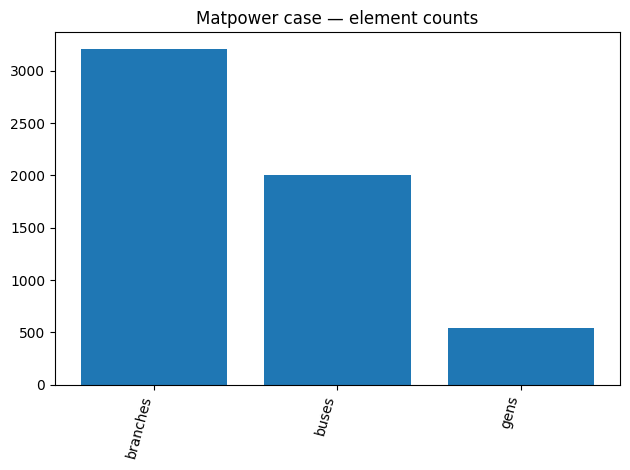

In [8]:
bar_counts(ds.counts_for_plot(), "Matpower case — element counts", top_n=10)

---
#### Basic quality checks
- missing/duplicate bus IDs
- null rates on key columns

In [9]:
checks = ds.duplicate_and_empty_checks()
checks


{'bus_id_null': 0,
 'bus_id_duplicates': 0,
 'branch_null_pct': {'from_bus': 0.0,
  'to_bus': 0.0,
  'BR_R': 0.0,
  'BR_X': 0.0,
  'BR_STATUS': 0.0},
 'gen_null_pct': {'bus_id': 0.0, 'PG': 0.0, 'QG': 0.0, 'GEN_STATUS': 0.0}}

---
#### Endpoint integrity
- branches reference existing buses
- generators reference existing buses

In [10]:
integrity = ds.endpoint_integrity()
integrity

{'branch_bad_from_bus_count': 0,
 'branch_bad_to_bus_count': 0,
 'branch_bad_from_bus_sample': [],
 'branch_bad_to_bus_sample': [],
 'gen_bad_bus_count': 0,
 'gen_bad_bus_sample': []}

---
#### Connectivity (union-find)
Connectivity on the bus graph using in-service branches (if `BR_STATUS` exists).

In [11]:
conn = ds.connectivity_stats(include_only_in_service=True)
pd.Series(conn, name="connectivity")

nodes                       2000
edges                       3206
connected_components           1
largest_component_size      2000
top_component_sizes       [2000]
isolated_buses_count           0
isolated_buses_sample         []
edges_only_in_service       True
Name: connectivity, dtype: object

---
#### Connectivity graph (networkx sanity view)
Undirected connectivity view for small-case visual inspection.

In [12]:
if bus is not None and branch is not None and "bus_id" in bus.columns:
    nodes = bus["bus_id"].dropna().astype(int).tolist()

    br = branch
    if "in_service" in br.columns:
        br = br[br["in_service"].fillna(False)]

    edges = []
    if "from_bus" in br.columns and "to_bus" in br.columns:
        edges = list(zip(br["from_bus"].dropna().astype(int), br["to_bus"].dropna().astype(int)))

    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    isolated = sorted([n for n, d in G.degree() if d == 0])

    {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "connected_components": nx.number_connected_components(G) if G.number_of_nodes() else 0,
        "isolated_buses_count": len(isolated),
        "isolated_buses_sample": isolated[:20],
    }

---
#### Topology sketch
Spring layout; useful only for small cases.

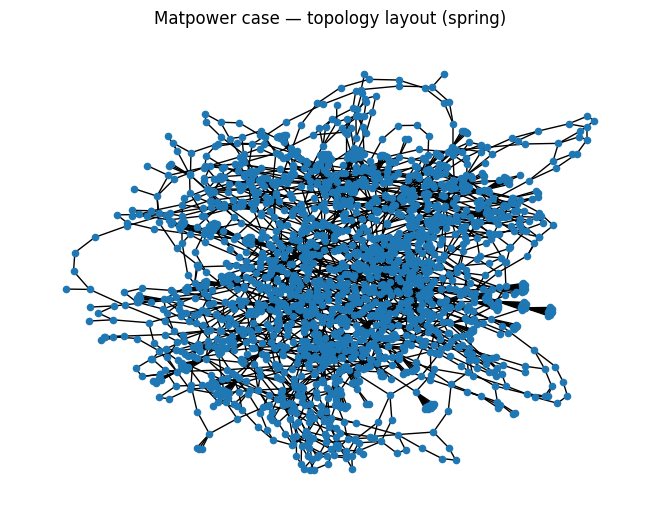

In [13]:
if "G" in globals() and G.number_of_nodes() and G.number_of_edges() and G.number_of_nodes() <= 5000:
    plt.figure()
    pos = nx.spring_layout(G, seed=1)
    nx.draw(G, pos=pos, node_size=20, with_labels=False)
    plt.title("Matpower case — topology layout (spring)")
    plt.show()

---
#### Export ML-ready artifacts (optional)
Writes nodes/edges/tables + metadata + manifest under `data/processed/`.

In [14]:
out = ds.export_ml_ready(
    format="parquet",
    force=True,
    include_only_in_service=False,
    manifest_version="v1",
)
out

{'output_dir': '/home/user/workspace/datasets-utilities/data/processed/matpower_case/ACTIVSg2000/default/v1',
 'artifacts': {'nodes': 'nodes.parquet',
  'edges': 'edges.parquet',
  'tables': {'branch': 'tables/branch.parquet',
   'bus': 'tables/bus.parquet',
   'gen': 'tables/gen.parquet',
   'gencost': 'tables/gencost.parquet'},
  'metadata': 'metadata.json',
  'manifest': 'manifest.json'},
 'counts': {'source': {'bus': 2000,
   'branch': 3206,
   'gen': 544,
   'gencost': 544},
  'export': {'nodes': 2000,
   'edges': 3206,
   'tables': {'bus': 2000, 'gen': 544, 'gencost': 544, 'branch': 3206}}},
 'metadata': {'dataset': 'matpower_case',
  'source_format': 'matpower',
  'input_path': '/home/user/data/datasets/activsg2000/ACTIVSg2000.m',
  'file_sha256': '55e140511bcc527e2c4302a723f40300b1e26fa1679bddec025138930f01c1ef',
  'mpc.version': '2',
  'mpc.baseMVA': 100.0,
  'counts': {'bus': 2000, 'branch': 3206, 'gen': 544, 'gencost': 544}},
 'schema_hash': '6e045fb8853d9f68c05d209f47e6f793